# Trabajo Práctico 2 - Minería de Datos
# Año: 2025


# Carga librerías y datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns
from sklearn import tree
from sklearn import decomposition
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text, export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
import itertools
import warnings
warnings.filterwarnings("ignore")
import copy
from graphviz import Source
from sklearn.preprocessing import KBinsDiscretizer



In [ ]:
file_companies = 'https://raw.githubusercontent.com/guillericci/TP2-DataMining/refs/heads/main/1000_Companies.csv'
file_drug= 'https://raw.githubusercontent.com/guillericci/TP2-DataMining/refs/heads/main/drugType.csv'
data_companies = pd.read_csv(file_companies)
data_drug = pd.read_csv(file_drug)

# Análisis exploratorio Dataset Companies

Visualizamos la dimensión del dataset.

In [ ]:
data_companies.shape

(1000, 5)

Visualizamos los valores faltantes y tipo de datos de las variables.

In [ ]:
data_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


Podemos observar que no hay valores faltantes.

Procedemos a obtener algunos de los datos de nuestro dataset para visualizar su estructura.

In [ ]:
data_companies.head()

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Ahora, visualizaremos de forma general la principales medidas descriptivas de las variables cuantitativas a considerar.

In [ ]:
data_companies.describe()

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


Analizamos la distribución de las variables categóricas.

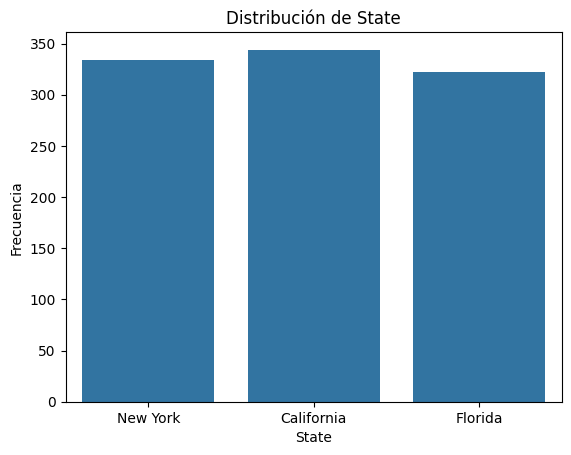

In [ ]:
sns.countplot(data=data_companies, x='State')
plt.title('Distribución de State')
plt.xlabel('State')
plt.ylabel('Frecuencia')
plt.show()

Visualizamos la matriz de correlación para observar la relación lineal entre las variables explicativas.

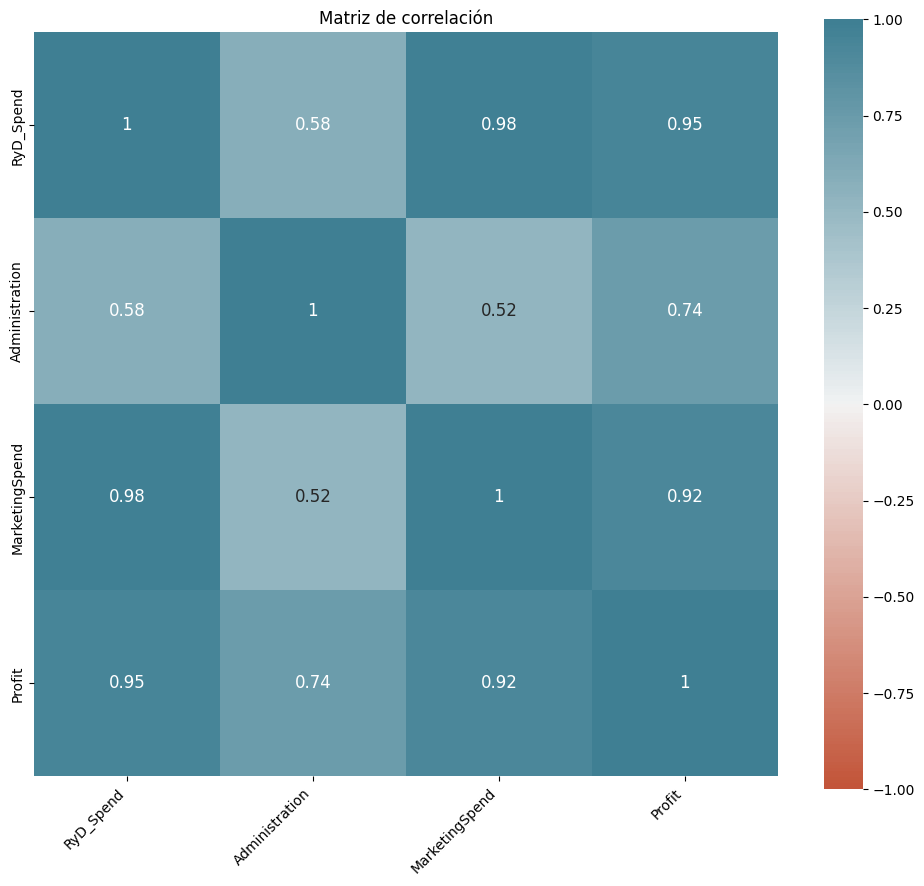

In [ ]:
data_num = data_companies.select_dtypes(include=['float64', 'int64'])
# Calcular la matriz de correlación
corr = data_num.corr()
# Crear una figura más grande
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 12}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

Observamos correlación positiva entre todas las variables, teniendo algunas una alta correlación. Analizaremos la dispersión entre si de todas las variables numéricas.

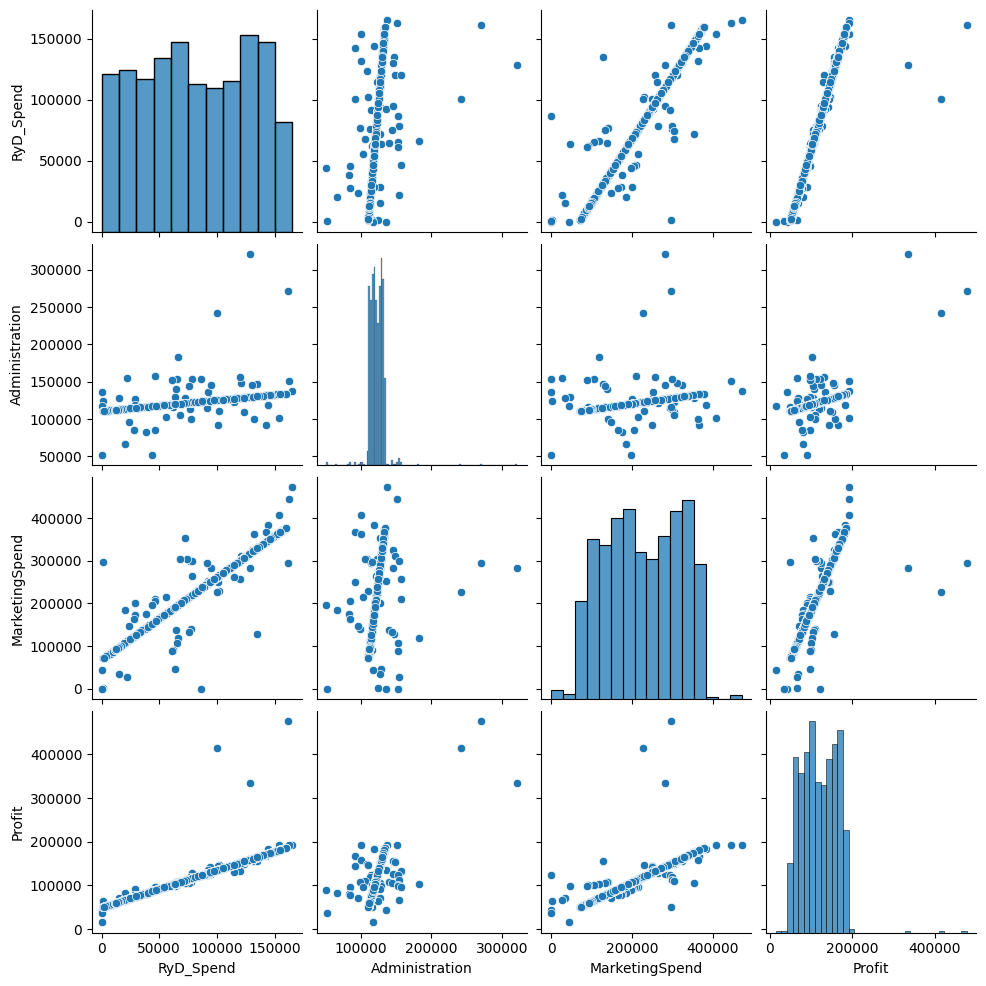

In [ ]:
sns.pairplot(data_companies)
plt.show()

Se observan relaciones lineales positivas entre las variables con algunos valores que se alejas de dicha tendencia. Se observa una correspondencia entre los valores extremos de Administración y Profit.

## Analisis de valores atípicos

Visualizamos la dispersión de las variables cuantitativas y si poseen valores atípicos.

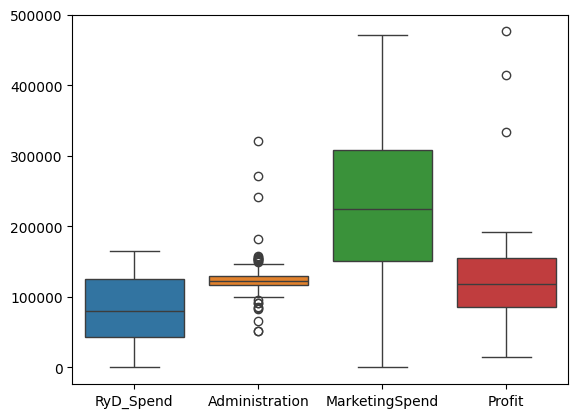

In [ ]:
sns.boxplot(data=data_companies)
plt.show()

Podemos observar que administración y profit tienen valores atípicos. Visualizamos su distribución.

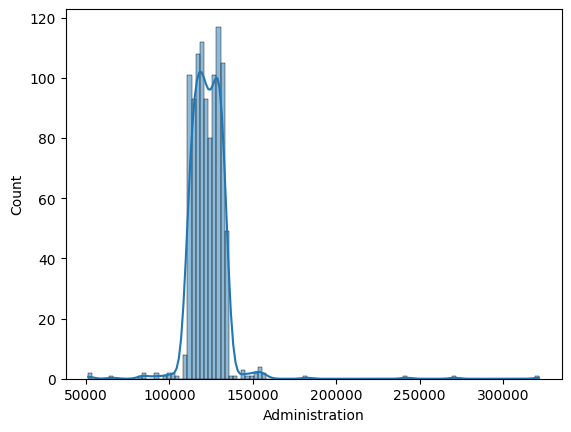

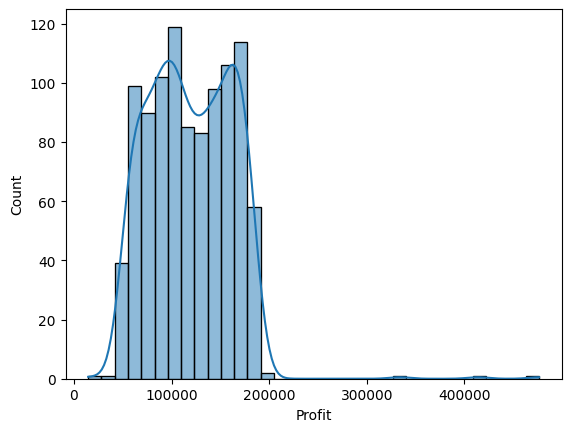

In [ ]:
for col in ['Administration', 'Profit']:
  sns.histplot(x = col, kde = True, data = data_companies)
  plt.show()


En el gráfico de dispersión podemos visualizar como los valores extremos de Profit se corresponden con valores extremos (los de mayor valor) de Aministración, indicando una relación entre los mismos. Siendo que el resto de los valores extremos parecen corresponderse a la natulareza del dataset, que puede variar la inversión en algunos sectores según las distintas compañías y que trabajaremos con árboles de decisión de regresión (no son tan sensibles a los outliers), no imputaremos ni eliminaremos los mismos.

# División Train/Test

Dividimos el dataset en train y test antes del escalado del mismo.

In [ ]:
# Guardamos las etiquetas de la variable target y la eliminamos
y = data_companies['Profit']
X = data_companies.drop(columns=['Profit'])


# división: 80% para train+val, 20% para test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# división: 70% para train+val, 30% para test
X_temp_30, X_test_30, y_temp_30, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)

# Segunda división: 80% de X_temp para train, 20% para val → da 64% train, 16% val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Segunda división: 70% de X_temp para train, 30% para val → da 56% train, 14% val
X_train_30, X_val_30, y_train_30, y_val_30 = train_test_split(X_temp_30, y_temp_30, test_size=0.2, random_state=42)

# Definir variables
categorical_features = ['State']
numerical_features = X_train.drop(columns=categorical_features).columns.tolist()

#Codificación y estandarización

Por medio de un preprocesador estadarizamos las variables númericas con StandarScaler y codificamos con OneHotEncoder las variables categóricas.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), categorical_features)],
    remainder='drop'
)

# Fit en X_train y transform ambos conjuntos para los datos divididos en 80/20
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_val_processed = preprocessor.transform(X_val)

# Fit en train para los datos divididos en 70/30
X_train_processed_30 = preprocessor.fit_transform(X_train_30)
X_test_processed_30 = preprocessor.transform(X_test_30)
X_val_processed_30 = preprocessor.transform(X_val_30)

feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)
X_val_processed = pd.DataFrame(X_val_processed, columns=feature_names)

X_train_processed_30 = pd.DataFrame(X_train_processed_30, columns=feature_names)
X_test_processed_30 = pd.DataFrame(X_test_processed_30, columns=feature_names)
X_val_processed_30 = pd.DataFrame(X_val_processed_30, columns=feature_names)

X_train_processed.head()
X_train_processed_30.head()

,RyD_Spend,Administration,MarketingSpend,State_Florida,State_New York
0,0.884840,0.480019,0.865846,0.0,1.0
1,-1.550855,-0.885055,-1.539239,0.0,0.0
2,-1.558475,-0.889325,-1.546763,0.0,1.0
3,1.091213,0.595680,1.069625,0.0,1.0
4,0.033668,0.002984,0.025371,1.0,0.0


# Modelo de Regresión con árboles de decisión


Realizamos ajuste de hiperparámetros utilizando una búsqueda exhaustiva sobre varias combinaciones de parámetros.


In [ ]:
max_depths = [3, 4, 5, None]
min_samples_splits = [2, 10]
min_samples_leafs = [1, 5]
criterions = ['squared_error', 'absolute_error']

results = []

for max_depth, min_split, min_leaf, crit in itertools.product(max_depths, min_samples_splits, min_samples_leafs, criterions):
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        criterion=crit,
        random_state=42
    )
    model.fit(X_train_processed, y_train)
    y_pred_val = model.predict(X_val_processed)

    mae = mean_absolute_error(y_val, y_pred_val)
    mse = mean_squared_error(y_val, y_pred_val)
    rmse = np.sqrt(mse)

    results.append({
        'max_depth': max_depth,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'criterion': crit,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values('RMSE'))

    max_depth  min_samples_split  min_samples_leaf       criterion  \
29        NaN                 10                 1  absolute_error   
26        NaN                  2                 5   squared_error   
30        NaN                 10                 5   squared_error   
28        NaN                 10                 1   squared_error   
25        NaN                  2                 1  absolute_error   
18        5.0                  2                 5   squared_error   
22        5.0                 10                 5   squared_error   
27        NaN                  2                 5  absolute_error   
31        NaN                 10                 5  absolute_error   
20        5.0                 10                 1   squared_error   
16        5.0                  2                 1   squared_error   
24        NaN                  2                 1   squared_error   
19        5.0                  2                 5  absolute_error   
17        5.0       

Utilizamos los hiperparámetros óptimos:
* max_depth= NaN
* min_samples_split=10,
* min_samples_leaf=1,
* criterion='absolute_error'


In [ ]:
# Modelo con hiperparámetros óptimos
model_20 = DecisionTreeRegressor(
    min_samples_split=10,
    min_samples_leaf=1,
    criterion='absolute_error',
    random_state=42
)

model_20.fit(X_train_processed, y_train)

model_30 =  copy.copy(model_20)
#entrenamos la copia del modelo con el otro conjunto de entrenamiento (70/30)
model_30.fit(X_train_processed_30, y_train_30)

DecisionTreeRegressor(criterion='absolute_error', min_samples_split=10,
                      random_state=42)

Visualizamos el Árbol de Decisión.

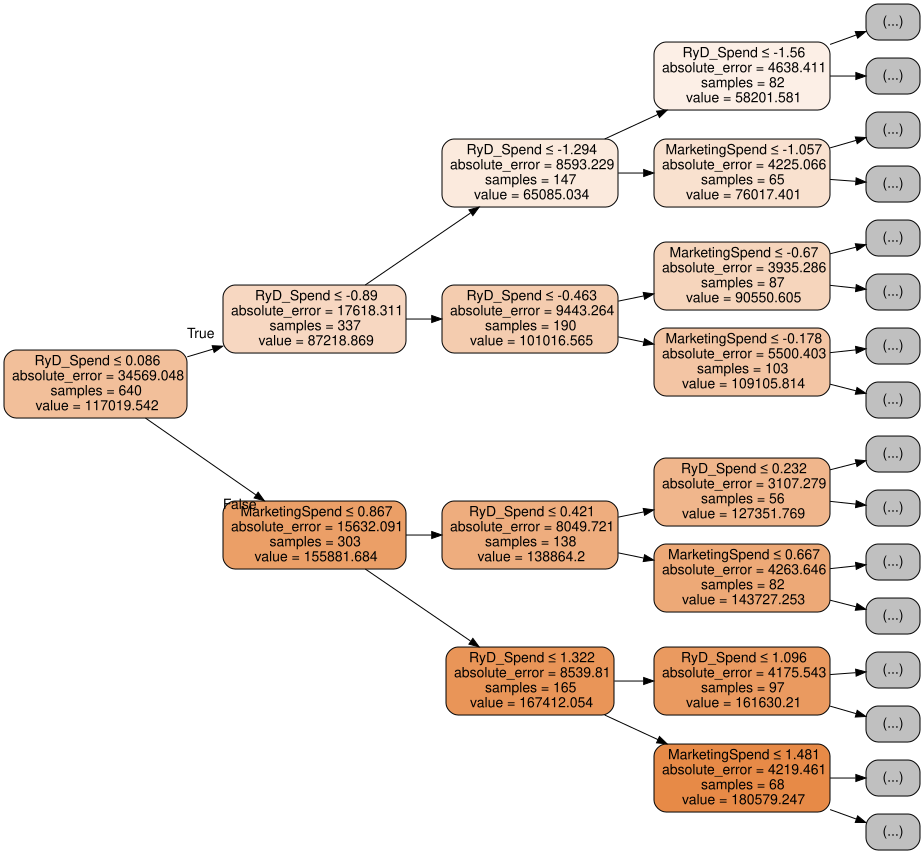

In [ ]:
# Exportar el árbol a un archivo .dot con poda visual hasta profundidad 3
export_graphviz(
    model_20,  # modelo de árbol entrenado
    out_file="tree_regression.dot",
    feature_names=feature_names,
    filled=True,
    rounded=True,
    special_characters=True,
    rotate=True,
    max_depth=10
)

# Leer y visualizar el archivo .dot con Graphviz
Source.from_file("tree_regression.dot")

Visualizamos la influencia de las variables en la target.

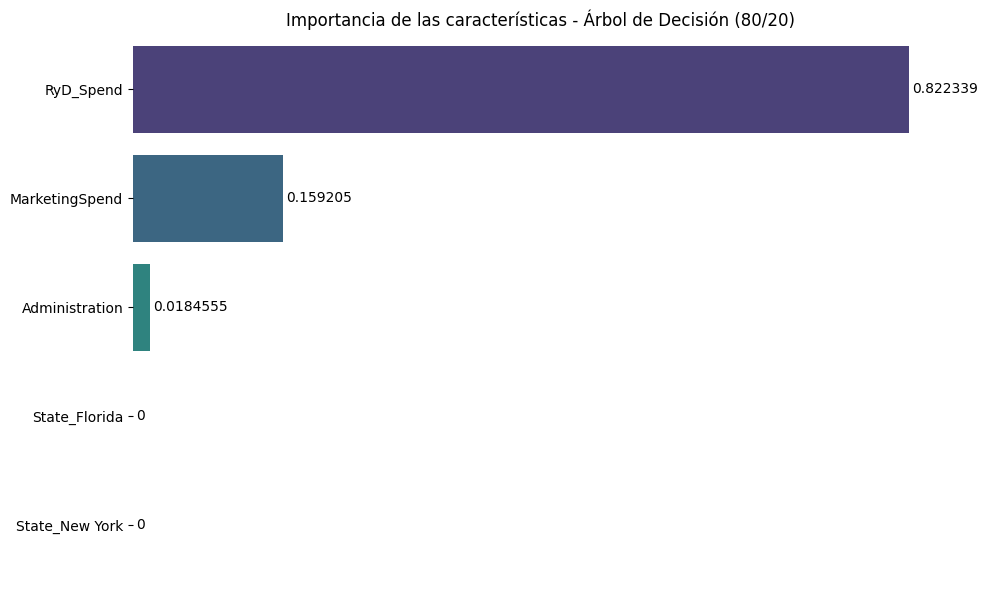

In [ ]:
# Crear DataFrame con las importancias
features_df = pd.DataFrame({
    'features': feature_names,
    'importances': model_20.feature_importances_
})

# Ordenar por importancia descendente
features_df_sorted = features_df.sort_values(by='importances', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
g = sns.barplot(data=features_df_sorted, x='importances', y='features', palette='viridis')
sns.despine(bottom=True, left=True)

g.set_title('Importancia de las características - Árbol de Decisión (80/20)')
g.set(xlabel=None, ylabel=None, xticks=[])

# Mostrar los valores sobre las barras
for value in g.containers:
    g.bar_label(value, padding=2)

plt.tight_layout()
plt.show()

Observamos R&D Spend tiene un peso significativamente mayor en la predicción de Profit, lo cual es consistente con el comportamiento esperado en empresas donde la inversión en investigación y desarrollo está correlacionada con las ganancias. Visualizamos también un impacto bajo de Administration y nulo de State.



Calculamos las métricas de error.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred_test_20 = model_20.predict(X_test_processed)

# calculamos el MAPE promediando estos errores.
mape_20 = np.mean(np.abs((y_test - y_pred_test_20) / y_test)) * 100

# Métricas en test
mae_20 = mean_absolute_error(y_test, y_pred_test_20)
mse_20 = mean_squared_error(y_test, y_pred_test_20)
rmse_20 = np.sqrt(mse_20)

print("Métricas Test para división Train/Test de 80/20")
print(f"Error Absoluto Medio (MAE): {mae_20:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_20:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_20:.2f}")
print("Porcentaje de error medio absoluto (MAPE):", mape_20)

Métricas Test para división Train/Test de 80/20
Error Absoluto Medio (MAE): 1511.69
Error Cuadrático Medio (MSE): 182903401.34
Raíz del Error Cuadrático Medio (RMSE): 13524.18
Porcentaje de error medio absoluto (MAPE): 0.8338289487284903


Graficamos las predicciones en función de los valores reales. La línea indica una predicción perfecta.

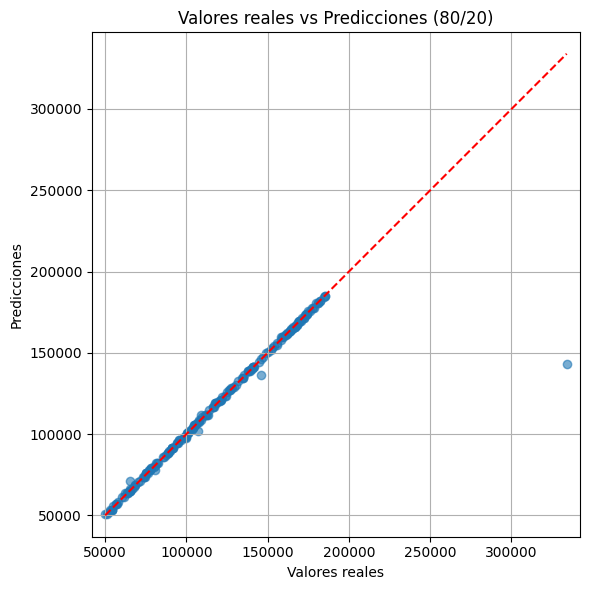

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_20, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs Predicciones (80/20)")
plt.axis("equal")  # Igual escala en ambos ejes

# Línea de referencia
min_test_20 = min(y_test.min(), y_pred_test_20.min())
max_test_20 = max(y_test.max(), y_pred_test_20.max())
plt.plot([min_test_20, max_test_20], [min_test_20, max_test_20], 'r--')

plt.grid(True)
plt.tight_layout()
plt.show()


Observamos una buena predicción con excepción de un dato que posee un error muy grande.

Procederemos a analizar el modelo con división Train/Test de 70/30.

Visualizamos el Árbol de Decisión con poda en profundidad igual a 3.

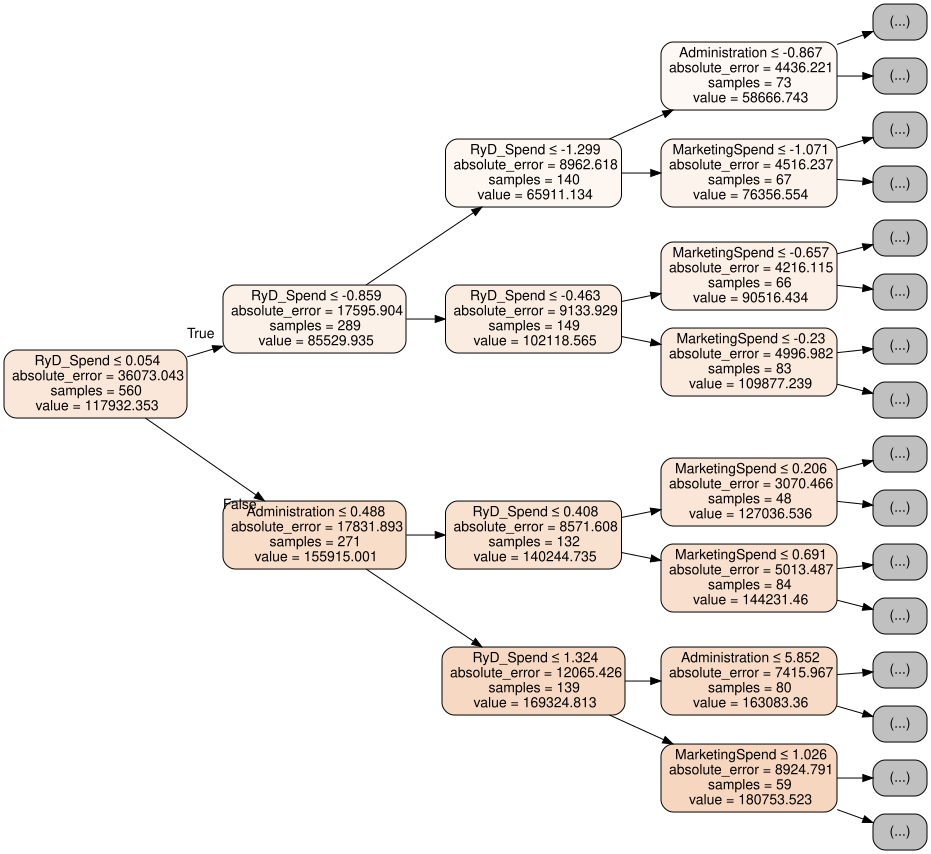

In [ ]:
# Exportar el árbol a un archivo .dot con poda visual hasta profundidad 3
export_graphviz(
    model_30,  # modelo de árbol entrenado
    out_file="tree_regression.dot",
    feature_names=feature_names,
    filled=True,
    rounded=True,
    special_characters=True,
    rotate=True,
    max_depth=3  # poda visual a profundidad 3
)

# Leer y visualizar el archivo .dot con Graphviz
Source.from_file("tree_regression.dot")

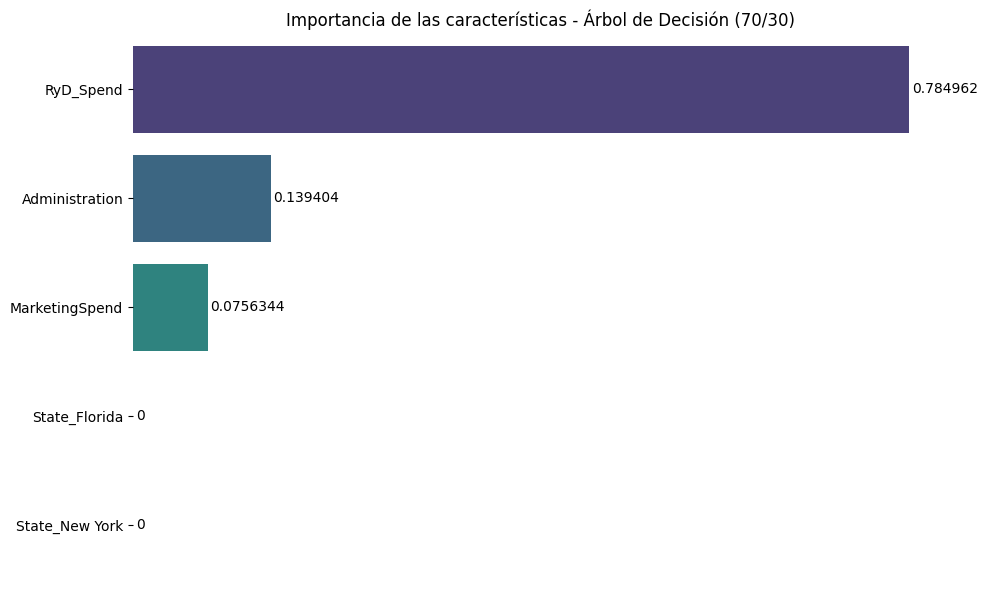

In [ ]:
# Crear DataFrame con las importancias
features_df_30 = pd.DataFrame({
    'features': feature_names,
    'importances': model_30.feature_importances_
})

# Ordenar por importancia descendente
features_df_sorted_30 = features_df_30.sort_values(by='importances', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
g = sns.barplot(data=features_df_sorted_30, x='importances', y='features', palette='viridis')
sns.despine(bottom=True, left=True)

g.set_title('Importancia de las características - Árbol de Decisión (70/30)')
g.set(xlabel=None, ylabel=None, xticks=[])

# Mostrar los valores sobre las barras
for value in g.containers:
    g.bar_label(value, padding=2)

plt.tight_layout()
plt.show()

Observamos una mayor influencia de Administration con respecto a el primer modelo.

Calculamos métricas de error.

In [ ]:
y_pred_train_30 = model_30.predict(X_train_processed_30)
y_pred_test_30 = model_30.predict(X_test_processed_30)

# calculamos el MAPE promediando estos errores.
mape_30 = np.mean(np.abs((y_test_30 - y_pred_test_30) / y_test_30)) * 100

# Métricas en test
mae_30 = mean_absolute_error(y_test_30, y_pred_test_30)
mse_30 = mean_squared_error(y_test_30, y_pred_test_30)
rmse_30 = np.sqrt(mse_30)
print("Métricas para división Train/Test de 70/30")
print(f"Error Absoluto Medio (MAE): {mae_30:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_30:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_30:.2f}")
print("Porcentaje de error medio absoluto (MAPE):", mape_30)

Métricas para división Train/Test de 70/30
Error Absoluto Medio (MAE): 1207.43
Error Cuadrático Medio (MSE): 32775670.64
Raíz del Error Cuadrático Medio (RMSE): 5725.00
Porcentaje de error medio absoluto (MAPE): 1.8156187641561108


El segundo modelo mejora en los errores absolutos pero aumenta en el error relativo (MAPE).

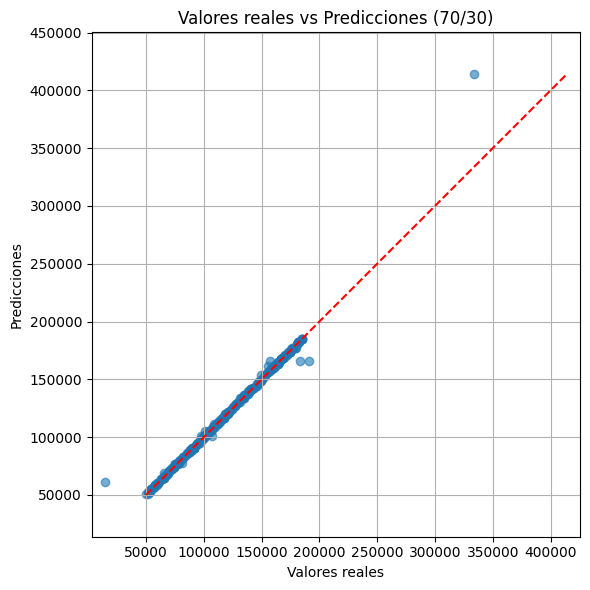

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_30, y_pred_test_30, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs Predicciones (70/30)")
plt.axis("equal")  # Igual escala en ambos ejes

# Línea de referencia (predicción perfecta)
min_test_30 = min(y_test.min(), y_pred_test_30.min())
max_test_30 = max(y_test.max(), y_pred_test_30.max())
plt.plot([min_test_30, max_test_30], [min_test_30, max_test_30], 'r--')

plt.grid(True)
plt.tight_layout()
plt.show()


# Conlusiones

Con un Error Absoluto Medio (MAE) de 1.511,69 y una Raíz del Error Cuadrático Medio (RMSE) de 13.524,18, se concluye que el modelo de regresión basado en árboles de decisión comete errores bajos en términos absolutos, especialmente considerando que los valores de Profit se encuentran en un rango aproximado de 0 a 500.000. En promedio, el modelo comete un error de tan solo 0,83% respecto al valor real de Profit, según lo indica el MAPE, lo que refleja un muy buen desempeño predictivo relativo.

Al modificar la proporción de entrenamiento y prueba a un 70/30 , se obtuvo un MAE de 1.207,43, un RMSE de 5.725,00 y un MAPE de 1,82%, mostrando una mejora en los errores absolutos pero un aumento en el error relativo (MAPE).

Como podemos observar en el gráfico de valores reales vs predichos del primer modelo, un valor posee un error considerablemente grande, siendo el valor real cercano a cero, lo cual distorsiona el MAPE.

# Analisis exploratorio de Dataset drugType

Visualizamos la dimensión del dataset.

In [ ]:
data_drug.shape

(200, 6)

Visualizamos los valores faltantes y tipo de datos de las variables.

In [ ]:
data_drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        200 non-null    int64  
 1   Sexo        200 non-null    object 
 2   BP          200 non-null    object 
 3   Colesterol  200 non-null    object 
 4   Na_a_K      200 non-null    float64
 5   Droga       200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Notamos que no hay valores faltantes en el dataset.

Procedemos a obtener algunos de los datos de nuestro dataset para visualizar su estructura.

In [ ]:
data_drug.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,Alto,Alto,25.355,DrogaY
1,47,M,Bajo,Alto,13.093,DrogaC
2,47,M,Bajo,Alto,10.114,DrogaC
3,28,F,Normal,Alto,7.798,DrogaX
4,61,F,Bajo,Alto,18.043,DrogaY


In [ ]:
print(data_drug['Sexo'].value_counts())
print(data_drug['BP'].value_counts())
print(data_drug['Colesterol'].value_counts())

Sexo
M    104
F     96
Name: count, dtype: int64
BP
Alto      77
Bajo      64
Normal    59
Name: count, dtype: int64
Colesterol
Alto      103
Normal     97
Name: count, dtype: int64


Analizaremos las distribuciones de las variables categoricas

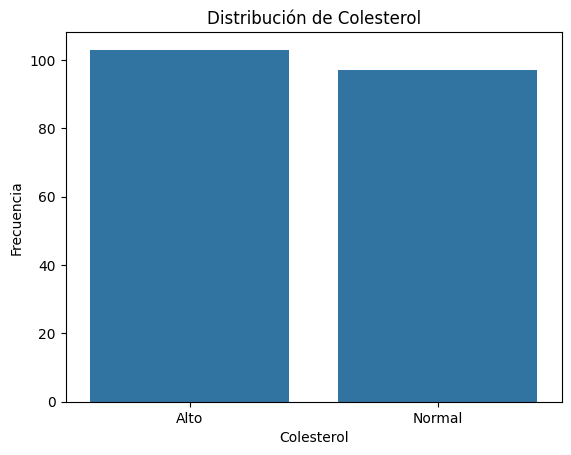

In [ ]:
sns.countplot(data=data_drug, x='Colesterol')
plt.title('Distribución de Colesterol')
plt.xlabel('Colesterol')
plt.ylabel('Frecuencia')
plt.show()

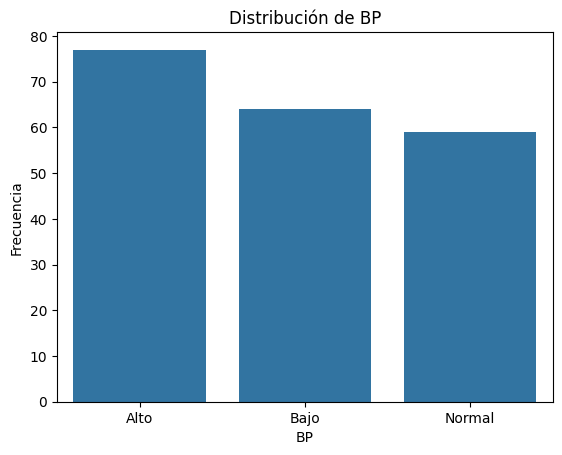

In [ ]:
sns.countplot(data=data_drug, x='BP')
plt.title('Distribución de BP')
plt.xlabel('BP')
plt.ylabel('Frecuencia')
plt.show()

Correlación de variables numéricas.

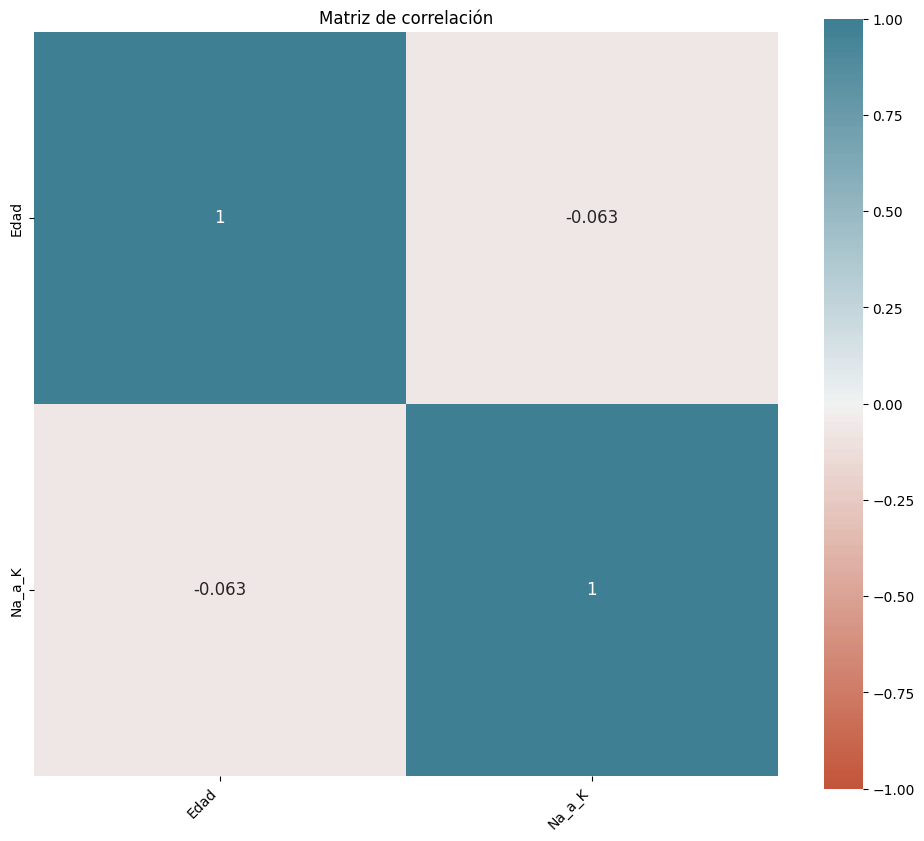

In [ ]:
data_num_2 = data_drug.select_dtypes(include=['float64', 'int64'])
# Calcular la matriz de correlación
corr_2 = data_num_2.corr()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_2,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 12}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

Visualizamos dispersión varibles numéricas diferenciando por la variable target.

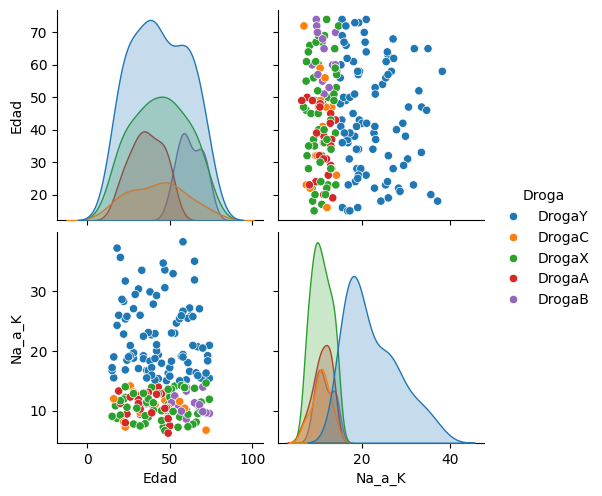

In [ ]:
sns.pairplot(data_drug, hue="Droga")
plt.show()

## Analisis de valores atipicos

Analizaremos los valores atipicos en las variables cuantitativas

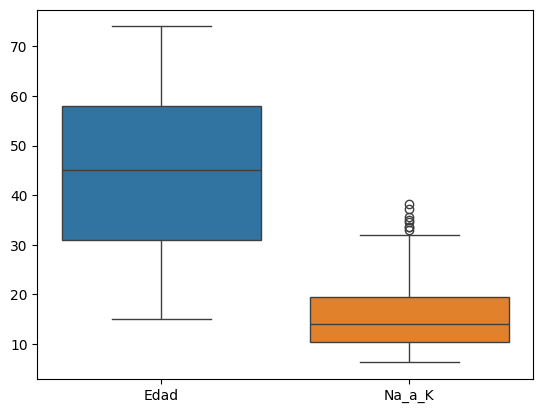

In [ ]:
sns.boxplot(data=data_drug)
plt.show()

In [ ]:
Q1 = data_drug['Na_a_K'].quantile(0.25)
Q3 = data_drug['Na_a_K'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = data_drug[(data_drug['Na_a_K'] < lim_inf) | (data_drug['Na_a_K'] > lim_sup)]
outliers.count().sum()

np.int64(48)

Hay 48 valores que superan el bigote superior de Na_a_K. Estos valores podrían no ser errores sino casos extremos válidos. Aplicaremos una transformacion logaritmica para reducir su impacto.

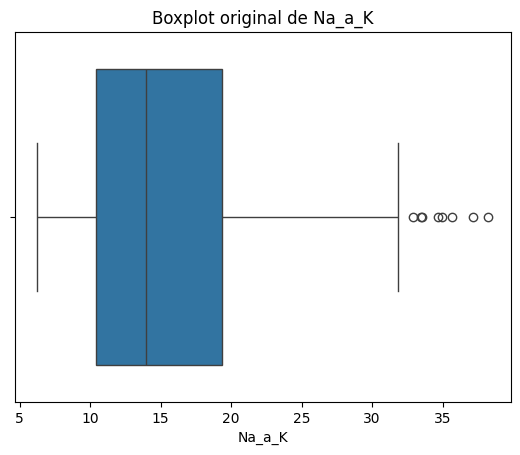

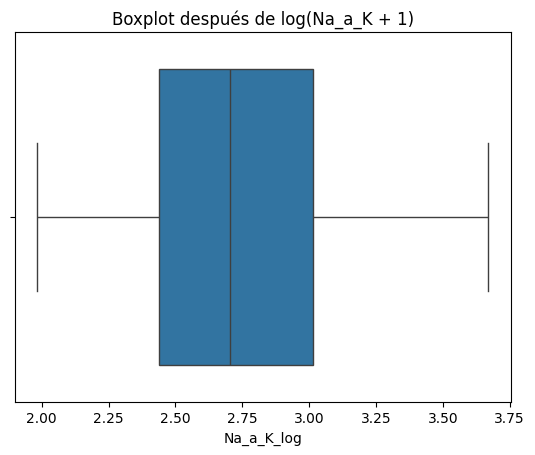

In [ ]:
data_drug['Na_a_K_log'] = np.log(data_drug['Na_a_K'] + 1)

# Antes de la transformación
sns.boxplot(x=data_drug['Na_a_K'])
plt.title('Boxplot original de Na_a_K')
plt.show()

# Después de la transformación
sns.boxplot(x=data_drug['Na_a_K_log'] )
plt.title('Boxplot después de log(Na_a_K + 1)')
plt.show()

In [ ]:
data_drug.drop('Na_a_K', axis=1, inplace=True)

In [ ]:
data_drug.sample(3)

,Edad,Sexo,BP,Colesterol,Droga,Na_a_K_log
190,58,M,Alto,Alto,DrogaY,2.995282
112,35,M,Bajo,Normal,DrogaX,2.319442
42,50,M,Normal,Normal,DrogaY,2.820783


## Division Train y Test

Dividimos en train y test, generando dos divisiones distintas.

In [ ]:
Xdrug = data_drug.drop('Droga', axis=1)
ydrug = data_drug['Droga']

numericas = ['Edad', 'Na_a_K_log']
categoricas = ['Sexo', 'BP', 'Colesterol']

X_train80, X_test20, y_train80, y_test20 = train_test_split(Xdrug, ydrug, test_size=0.2, random_state=42)
X_train70, X_test30, y_train70, y_test30 = train_test_split(Xdrug, ydrug, test_size=0.3, random_state=42)

# Codificacion y Estandarizacion

Usamos un preprocesador para estandarizar las variables númericas con StandarScaler y codificamos con OneHotEncoder las variables categóricas.

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(drop='first'), categoricas)
    ])

X_train80_procesado = preprocesador.fit_transform(X_train80)
X_test20_procesado = preprocesador.transform(X_test20)
X_train70_procesado = preprocesador.fit_transform(X_train70)
X_test30_procesado = preprocesador.transform(X_test30)

In [ ]:
# Obtener nombres de columnas numéricas y categóricas procesadas
num_features = preprocesador.named_transformers_['num'].get_feature_names_out(numericas)
cat_features = preprocesador.named_transformers_['cat'].get_feature_names_out(categoricas)

# Combinar en una sola lista
feature_names = np.concatenate([num_features, cat_features])

# Modelo de Clasificacion con Arboles de decisión

Realizamos la optimización de los  hiperparámetros mediante RandomizedSearchCV y entrenamos el modelo de Árbol de Decisión de Clasificación (train/test : 80/20).


In [ ]:
# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    "criterion": ['gini', 'entropy'],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 5],
    "min_samples_split": [2, 10]
}

# Búsqueda aleatoria con validación cruzada
random_search_20 = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=18),
    param_distributions=param_grid,
    n_iter=18,
    cv=5,
    random_state=42
)

random_search_30 = copy.copy(random_search_20)

# Entrenar la búsqueda
random_search_20.fit(X_train80_procesado, y_train80)

# Obtener los mejores hiperparámetros
first_best_params_20 = random_search_20.best_params_

# Predecir en el conjunto de test
best_prediction_20 = random_search_20.predict(X_test20_procesado)

# Calcular la precisión
test_accuracy_20 = accuracy_score(y_test20, best_prediction_20)

print(f"Mejores hiperparámetros para 80/20: {first_best_params_20}")
print(f"Precisión en test para 80/20: {test_accuracy_20:.4f}")


Mejores hiperparámetros para 80/20: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Precisión en test para 80/20: 1.0000


Visualizamos el Árbol de Decisión.

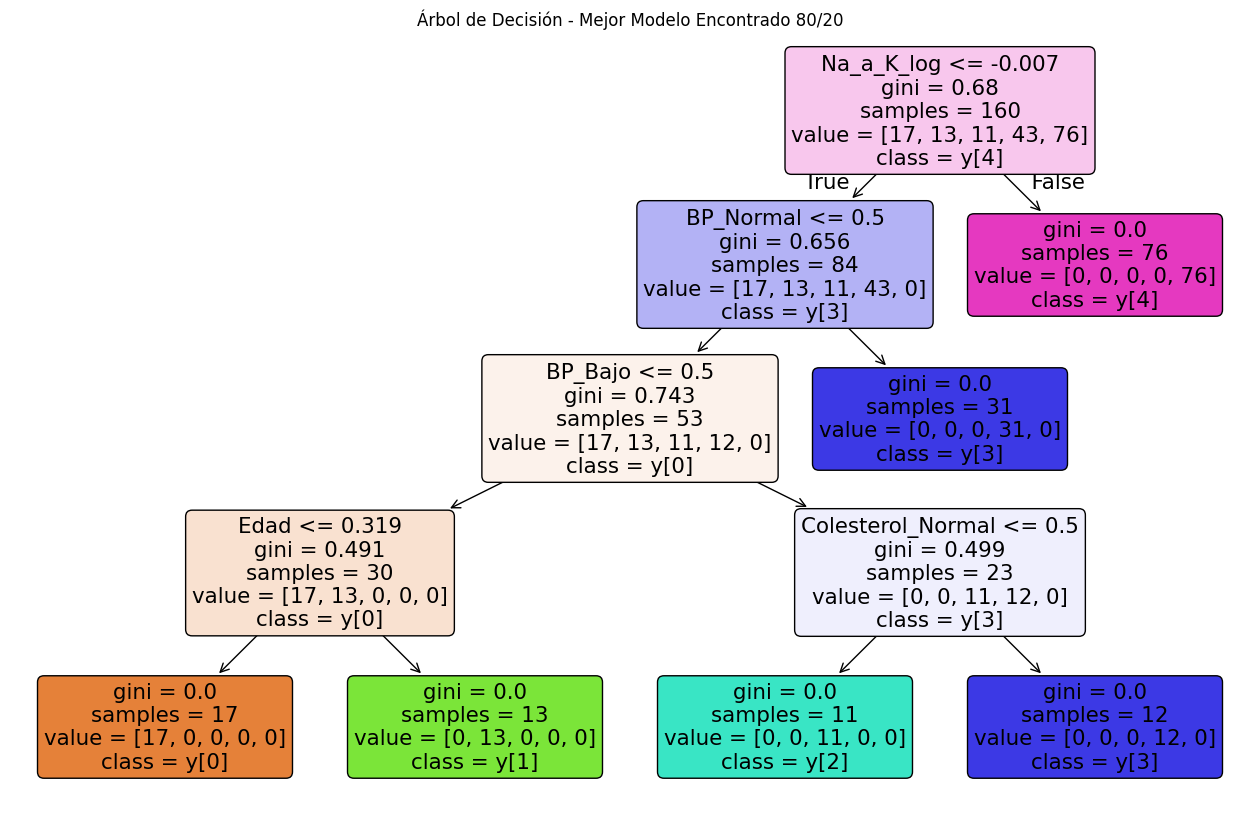

In [ ]:
best_model_20 = random_search_20.best_estimator_

plt.figure(figsize=(16, 10))
plot_tree(best_model_20, feature_names=feature_names, class_names=True, filled=True, rounded=True)
plt.title("Árbol de Decisión - Mejor Modelo Encontrado 80/20")
plt.show()


El modelo evalúa las condiciones en cada nodo y toma decisiones de clasificación a medida que recorre el árbol. El índice de Gini mide qué tan mezcladas están las clases en cada partición: cuanto menor es el valor, más pura es la división.

Al llegar a una hoja, el modelo realiza la predicción correspondiente a la clase mayoritaria en ese nodo.

Por ejemplo, si una persona presenta Na_a_k_log <= 0.007, un BP_normal <= 0.5,  un BP_baj0 <= 0.5 y Edad<=0.319 (valores transformados no reales) el modelo predice la clase correspondiente a y[0].

El árbol requirió una profundidad de 5 niveles para separar adecuadamente todas las clases.

In [ ]:
print(export_text(best_model_20, feature_names=list(feature_names)))


|--- Na_a_K_log <= -0.01
|   |--- BP_Normal <= 0.50
|   |   |--- BP_Bajo <= 0.50
|   |   |   |--- Edad <= 0.32
|   |   |   |   |--- class: DrogaA
|   |   |   |--- Edad >  0.32
|   |   |   |   |--- class: DrogaB
|   |   |--- BP_Bajo >  0.50
|   |   |   |--- Colesterol_Normal <= 0.50
|   |   |   |   |--- class: DrogaC
|   |   |   |--- Colesterol_Normal >  0.50
|   |   |   |   |--- class: DrogaX
|   |--- BP_Normal >  0.50
|   |   |--- class: DrogaX
|--- Na_a_K_log >  -0.01
|   |--- class: DrogaY



In [ ]:
random_search_20

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=18),
                   n_iter=18,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 4, 5],
                                        'min_samples_leaf': [1, 5],
                                        'min_samples_split': [2, 10]},
                   random_state=42)

Visualizamos métricas.


In [ ]:
# Métricas
accuracy_20 = accuracy_score(y_test20, best_prediction_20)
precision_20 = precision_score(y_test20, best_prediction_20, average='weighted')
recall_20 = recall_score(y_test20, best_prediction_20, average='weighted')
f1_20 = f1_score(y_test20, best_prediction_20, average='weighted')
confusion_20 = confusion_matrix(y_test20, best_prediction_20)


In [ ]:
print(f'Accuracy: {accuracy_20},\n\nPrecision: {precision_20},\n\nRecall: {recall_20},\n\nF1: {f1_20}')


Accuracy: 1.0,

Precision: 1.0,

Recall: 1.0,

F1: 1.0


Observamos que el modelo predice de manera perfecta.

In [ ]:
y_train80.value_counts()

,count
Droga,
DrogaY,76
DrogaX,43
DrogaA,17
DrogaB,13
DrogaC,11


Visualizamos la matriz de confusión.

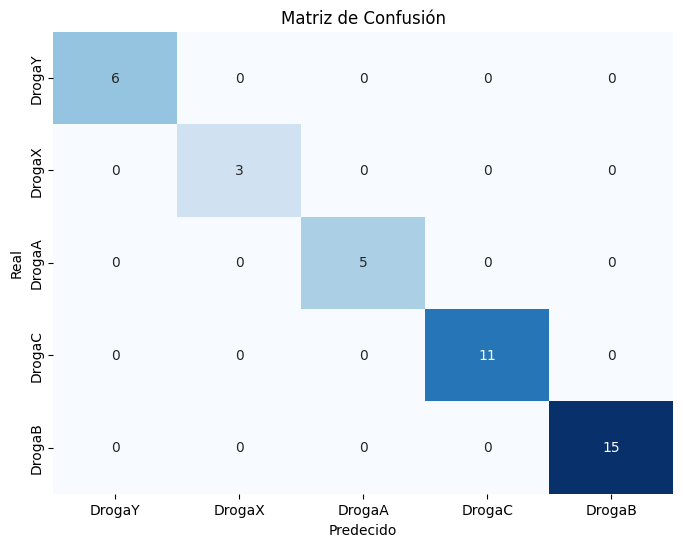

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_20, annot=True, fmt='d', cmap='Blues',
            xticklabels=["DrogaY", "DrogaX", "DrogaA", "DrogaC", "DrogaB"],
            yticklabels=["DrogaY", "DrogaX", "DrogaA", "DrogaC", "DrogaB"],
            cbar=False)
plt.xlabel('Predecido')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

Procederemos a analizar el modelo con división Train/Test de 70/30.

Optimizamos hiperparámetros.

In [ ]:
# Entrenar la búsqueda
random_search_30.fit(X_train70_procesado, y_train70)

# Obtener los mejores hiperparámetros
first_best_params_30 = random_search_30.best_params_

# Predecir en el conjunto de test
best_prediction_30 = random_search_30.predict(X_test30_procesado)

# Calcular la precisión
test_accuracy_30 = accuracy_score(y_test30, best_prediction_30)

print(f"Mejores hiperparámetros para 70/30: {first_best_params_30}")
print(f"Precisión en test para 70/30: {test_accuracy_30:.4f}")

Mejores hiperparámetros para 70/30: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Precisión en test para 70/30: 1.0000


Visualizamos Árbol de Decisión.

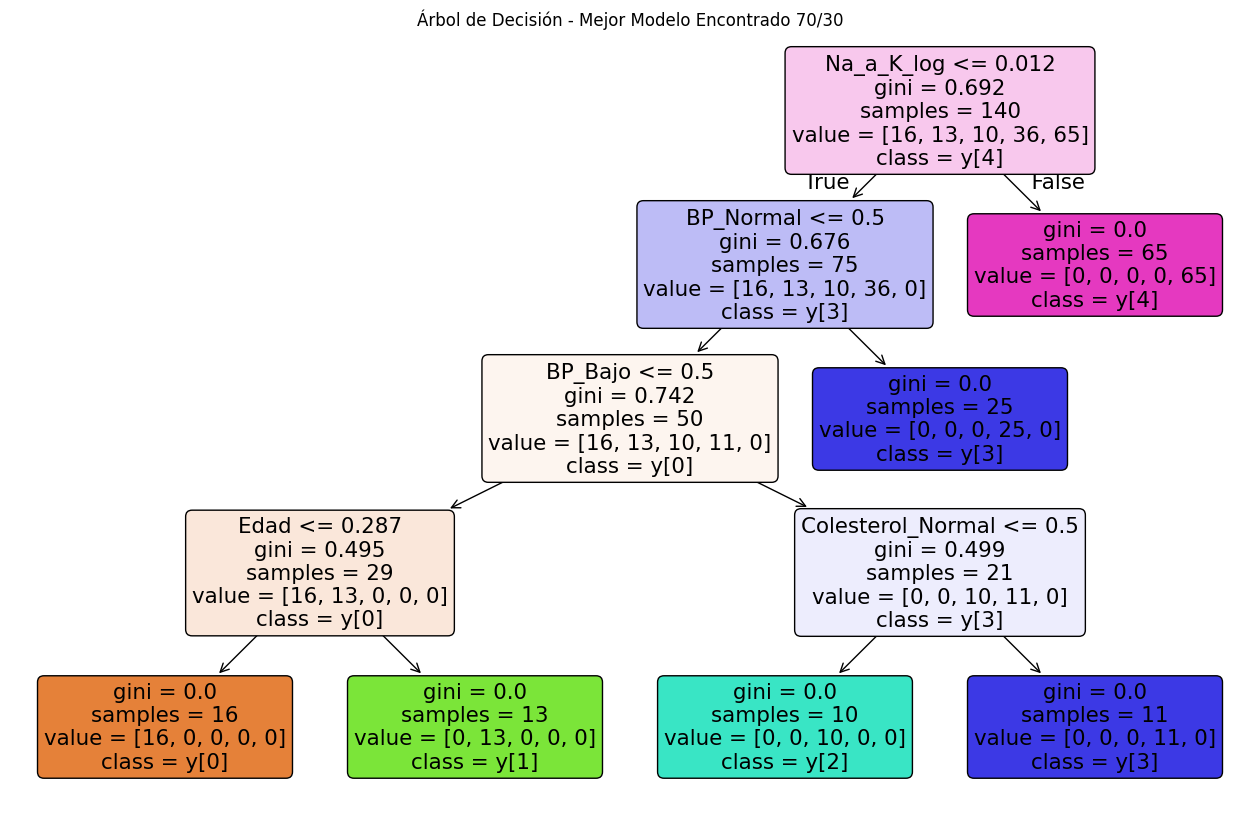

In [ ]:
best_model_30 = random_search_30.best_estimator_

plt.figure(figsize=(16, 10))
plot_tree(best_model_30, feature_names=feature_names, class_names=True, filled=True, rounded=True)
plt.title("Árbol de Decisión - Mejor Modelo Encontrado 70/30")
plt.show()


In [ ]:
print(export_text(best_model_30, feature_names=list(feature_names)))

|--- Na_a_K_log <= 0.01
|   |--- BP_Normal <= 0.50
|   |   |--- BP_Bajo <= 0.50
|   |   |   |--- Edad <= 0.29
|   |   |   |   |--- class: DrogaA
|   |   |   |--- Edad >  0.29
|   |   |   |   |--- class: DrogaB
|   |   |--- BP_Bajo >  0.50
|   |   |   |--- Colesterol_Normal <= 0.50
|   |   |   |   |--- class: DrogaC
|   |   |   |--- Colesterol_Normal >  0.50
|   |   |   |   |--- class: DrogaX
|   |--- BP_Normal >  0.50
|   |   |--- class: DrogaX
|--- Na_a_K_log >  0.01
|   |--- class: DrogaY



In [ ]:
random_search_30

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=18),
                   n_iter=18,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 4, 5],
                                        'min_samples_leaf': [1, 5],
                                        'min_samples_split': [2, 10]},
                   random_state=42)

Visualizamos Métricas.

In [ ]:
# Métricas
accuracy_30 = accuracy_score(y_test30, best_prediction_30)
precision_30 = precision_score(y_test30, best_prediction_30, average='weighted')
recall_30 = recall_score(y_test30, best_prediction_30, average='weighted')
f1_30 = f1_score(y_test30, best_prediction_30, average='weighted')
confusion_30 = confusion_matrix(y_test30, best_prediction_30)


In [ ]:
print(f'Accuracy: {accuracy_30},\n\nPrecision: {precision_30},\n\nRecall: {recall_30},\n\nF1: {f1_30}')

Accuracy: 1.0,

Precision: 1.0,

Recall: 1.0,

F1: 1.0


In [ ]:
y_train70.value_counts()

,count
Droga,
DrogaY,65
DrogaX,36
DrogaA,16
DrogaB,13
DrogaC,10


# Bayes Ingenuo

Antes de aplicar alguno de los métodos debemos analizar si discretizamos las variables numéricas.

Hay dos opciones, si las distribuciones son normales se puede aplicar GaussianNB. Sino hay que discretizar y podriamos aplicar MultinomialNB

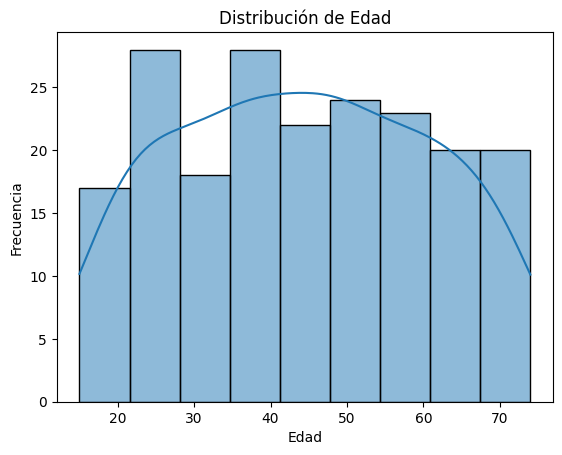

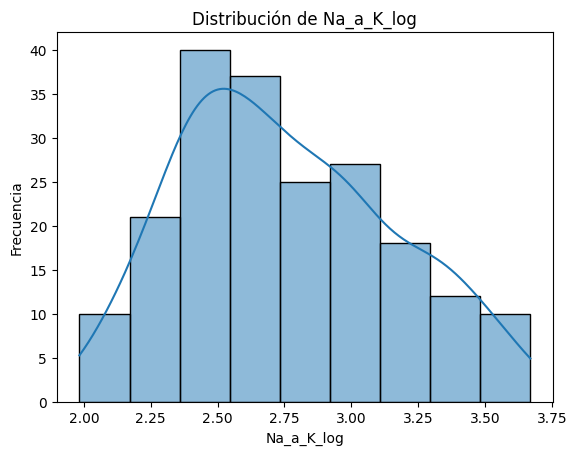

In [ ]:
#histograma para ver la distribucion de edad y Na_a_K_log
sns.histplot(data_drug['Edad'], kde=True)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
sns.histplot(data_drug['Na_a_K_log'], kde=True)
plt.title('Distribución de Na_a_K_log')
plt.xlabel('Na_a_K_log')
plt.ylabel('Frecuencia')
plt.show()

Aunque las distribuciones de las variables Edad y Na_a_K_log no son perfectamente normales, se observa una forma aproximadamente continua y unimodal en ambos casos.
Esto permite utilizar el clasificador GaussianNB, que asume distribución normal condicional para cada clase.
En la práctica, este clasificador suele ser robusto incluso ante pequeñas desviaciones de la normalidad.
También discretizaremos y aplicaremos MultinomialNB para comparar ambos enfoques.

## GaussianNB

Realizamos y entrenamos el modelo con GaussianNB para el split 80/20.

==== Evaluación con split 80/20 ====
              precision    recall  f1-score   support

      DrogaA       0.55      1.00      0.71         6
      DrogaB       0.75      1.00      0.86         3
      DrogaC       0.83      1.00      0.91         5
      DrogaX       1.00      0.91      0.95        11
      DrogaY       0.89      0.53      0.67        15

    accuracy                           0.80        40
   macro avg       0.80      0.89      0.82        40
weighted avg       0.85      0.80      0.80        40



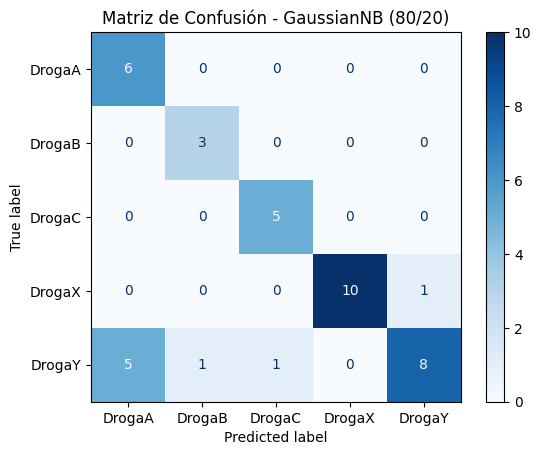

In [ ]:
# Crear el modelo
gnb_80 = GaussianNB()
gnb_80.fit(X_train80_procesado, y_train80)

# Predecir
y_pred20_gnb = gnb_80.predict(X_test20_procesado)

# Evaluar
print("==== Evaluación con split 80/20 ====")
print(classification_report(y_test20, y_pred20_gnb))

precision_GNB20 = precision_score(y_test20, y_pred20_gnb, average='macro')
accuracy_GNB20 = accuracy_score(y_test20, y_pred20_gnb)
recall_GNB20 = recall_score(y_test20, y_pred20_gnb, average='macro')

# Mostrar matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test20, y_pred20_gnb, cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - GaussianNB (80/20)")
plt.show()


Observamos buenas métricas en general exceptuando la precisión de DrogaA y recall de DrogaY. Eso se debe a que en 5 predicciones optó por DrogaA cuando la etiqueta verdadera era DrogaY, como se observa en la matriz de confusión.

Realizamos el modelo con GaussianNB para el split 70/30.

==== Evaluación con split 70/30 ====
              precision    recall  f1-score   support

      DrogaA       0.54      1.00      0.70         7
      DrogaB       0.50      1.00      0.67         3
      DrogaC       0.60      1.00      0.75         6
      DrogaX       1.00      1.00      1.00        18
      DrogaY       1.00      0.50      0.67        26

    accuracy                           0.78        60
   macro avg       0.73      0.90      0.76        60
weighted avg       0.88      0.78      0.78        60



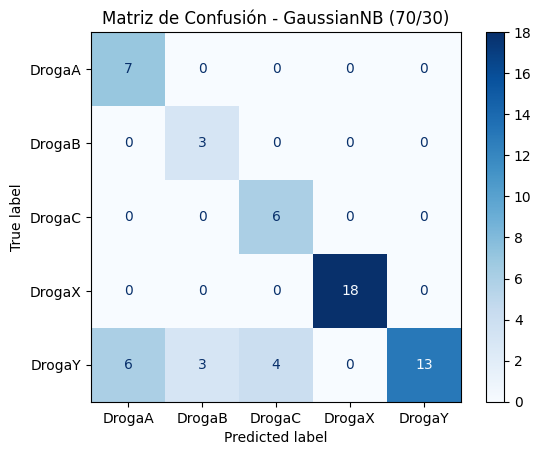

In [ ]:
# Crear y entrenar el modelo
gnb_70 = GaussianNB()
gnb_70.fit(X_train70_procesado, y_train70)

# Predecir
y_pred30_gnb = gnb_70.predict(X_test30_procesado)

# Evaluar
print("==== Evaluación con split 70/30 ====")
print(classification_report(y_test30, y_pred30_gnb))

precision_GNB30 = precision_score(y_test30, y_pred30_gnb, average='macro')
accuracy_GNB30 = accuracy_score(y_test30, y_pred30_gnb)
recall_GNB30 = recall_score(y_test30, y_pred30_gnb, average='macro')

# Mostrar matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test30, y_pred30_gnb, cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - GaussianNB (70/30)")
plt.show()


Observamos una precisión similar al modelo anterior en la DrogaA, y una reducción considerable en la precisión de DrogaB y DrogaC. El recall en DrogaY se mantiene en un valor similar y hay una leve mejoría en el recall de DrogaX.


Comparacion de metricas entre distintas divisiones de conjuntos

In [ ]:
metricas = pd.DataFrame({
    'Modelo': ['GaussianNB (70/30)', 'GaussianNB (80/20)'],
    'Precisión': [precision_GNB30, precision_GNB20],
    'Exactitud': [accuracy_GNB30, accuracy_GNB20],
    'Exhaustividad': [recall_GNB30, recall_GNB20]
})

print(metricas)

               Modelo  Precisión  Exactitud  Exhaustividad
0  GaussianNB (70/30)   0.727692   0.783333       0.900000
1  GaussianNB (80/20)   0.803535   0.800000       0.888485


Si bien el modelo con split 70/30 mejora levemente la Exhaustividad, empeora consirablemente en precisión y levemente en exactitud. Consideramos que el modelo con split 80/20 tiene mejores métricas y realiza mejores predicciones.


## MultinomialNB

 Discretizamos las variables numéricas en 3 bins usando quantiles para preparar los datos antes de aplicar un modelo con MultinomialNB.

In [ ]:
# Definimos discretizador
discretizador = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

# Aplicamos solo sobre las variables numéricas
X_train80_bin = X_train80.copy()
X_test20_bin = X_test20.copy()
X_train70_bin = X_train70.copy()
X_test30_bin = X_test30.copy()

X_train80_bin[numericas] = discretizador.fit_transform(X_train80[numericas])
X_test20_bin[numericas] = discretizador.transform(X_test20[numericas])
X_train70_bin[numericas] = discretizador.fit_transform(X_train70[numericas])
X_test30_bin[numericas] = discretizador.transform(X_test30[numericas])


In [ ]:
X_train80_bin.head()

,Edad,Sexo,BP,Colesterol,Na_a_K_log
79,0.0,F,Bajo,Normal,0.0
197,1.0,M,Normal,Alto,0.0
38,1.0,F,Normal,Normal,0.0
24,0.0,F,Bajo,Alto,2.0
122,0.0,M,Normal,Alto,2.0


In [ ]:
# Todas las variables ahora se tratan como categóricas
todas_cat = numericas + categoricas

preprocesador_mnb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), todas_cat)
    ],
    remainder='drop'
)

X_train80_mnb = preprocesador_mnb.fit_transform(X_train80_bin)
X_test20_mnb = preprocesador_mnb.transform(X_test20_bin)
X_train70_mnb = preprocesador_mnb.fit_transform(X_train70_bin)
X_test30_mnb = preprocesador_mnb.transform(X_test30_bin)

Realizamos y entrenamos el modelo con MultinomialNB.

              precision    recall  f1-score   support

      DrogaA       0.67      0.33      0.44         6
      DrogaB       0.00      0.00      0.00         3
      DrogaC       0.00      0.00      0.00         5
      DrogaX       1.00      0.55      0.71        11
      DrogaY       0.48      1.00      0.65        15

    accuracy                           0.57        40
   macro avg       0.43      0.38      0.36        40
weighted avg       0.56      0.57      0.51        40



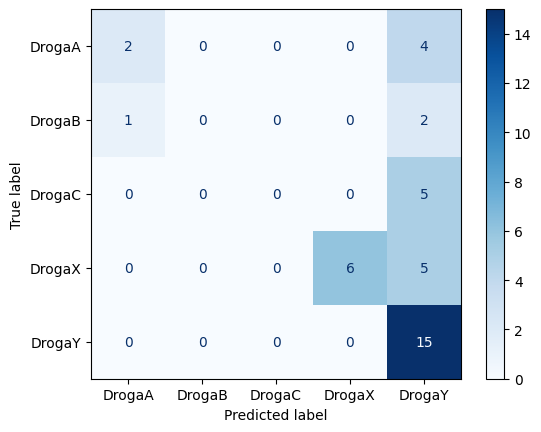

In [ ]:
modelo_mnb = MultinomialNB()
modelo_mnb.fit(X_train80_mnb, y_train80)

# Predecimos
y_pred20_mnb = modelo_mnb.predict(X_test20_mnb)

precision_MNB20 = precision_score(y_test20, y_pred20_mnb, average='macro')
accuracy_MNB20 = accuracy_score(y_test20, y_pred20_mnb)
recall_MNB20 = recall_score(y_test20, y_pred20_mnb, average='macro')

print(classification_report(y_test20, y_pred20_mnb))
ConfusionMatrixDisplay.from_predictions(y_test20, y_pred20_mnb,cmap=plt.cm.Blues)

Comparamos las metricas que devuelven los modelos de GaussianNB y MultinomialNB para un mismo conjunto Train/Test

In [ ]:
metricas = pd.DataFrame({
    'Modelo': ['MultinomialNB (80/20)', 'GaussianNB (80/20)'],
    'Precisión': [precision_MNB20, precision_GNB20],
    'Exactitud': [accuracy_MNB20, accuracy_GNB20],
    'Exhaustividad': [recall_MNB20, recall_GNB20]})
print(metricas)

                  Modelo  Precisión  Exactitud  Exhaustividad
0  MultinomialNB (80/20)   0.430108      0.575       0.375758
1     GaussianNB (80/20)   0.803535      0.800       0.888485


# k-NN

In [ ]:
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', KNeighborsClassifier())
])
parametros_grid = {
    'clasificador__n_neighbors': range(1, 20, 2),    # valores hasta el 19
    'clasificador__p': [1, 2],                       # Manhattan y Euclidiana
    'clasificador__weights': ['uniform', 'distance']
}

Buscamos los mejores hiperparametros del modelo con GridSearchCV

In [ ]:
grid_search_knn_80 = GridSearchCV(estimator=pipeline_knn,param_grid=parametros_grid,cv=5,scoring='accuracy')

grid_search_knn_80.fit(X_train80, y_train80)
print("Mejores hiperparámetros (80/20):", grid_search_knn_80.best_params_)

Mejores hiperparámetros (80/20): {'clasificador__n_neighbors': 13, 'clasificador__p': 1, 'clasificador__weights': 'distance'}


Evaluamos las metricas para el Test 20%


Classification Report (80/20):
              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00         6
      DrogaB       1.00      1.00      1.00         3
      DrogaC       1.00      1.00      1.00         5
      DrogaX       1.00      0.82      0.90        11
      DrogaY       0.88      1.00      0.94        15

    accuracy                           0.95        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.96      0.95      0.95        40

Accuracy: 0.95
Precision: 0.9764705882352942
Recall: 0.9636363636363636


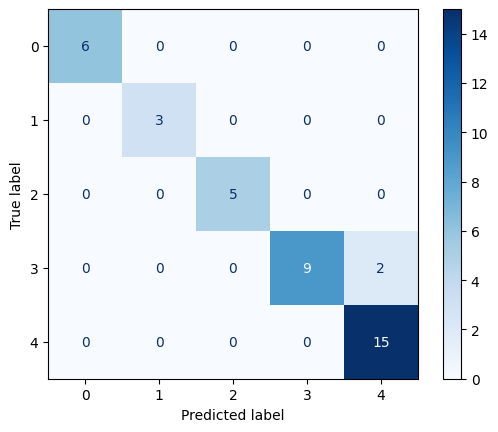

In [ ]:
pred_KNN80 = grid_search_knn_80.predict(X_test20)
cm_80 = confusion_matrix(y_test20, pred_KNN80)
ConfusionMatrixDisplay(confusion_matrix=cm_80).plot(cmap=plt.cm.Blues)
accuracy_KNN20 = accuracy_score(y_test20, pred_KNN80)
precision_KNN20 = precision_score(y_test20, pred_KNN80, average='macro')
recall_KNN20 = recall_score(y_test20, pred_KNN80, average='macro')
print("\nClassification Report (80/20):")
print(classification_report(y_test20, pred_KNN80))
print("Accuracy:", accuracy_KNN20)
print("Precision:", precision_KNN20)
print("Recall:", recall_KNN20)

In [ ]:
grid_search_knn_70 = GridSearchCV(estimator=pipeline_knn,param_grid=parametros_grid,cv=5,scoring='accuracy')

grid_search_knn_70.fit(X_train70, y_train70)
print("\nMejores hiperparámetros (70/30):", grid_search_knn_70.best_params_)


Mejores hiperparámetros (70/30): {'clasificador__n_neighbors': 19, 'clasificador__p': 1, 'clasificador__weights': 'distance'}


Evaluamos las metricas para el Test 30%


Classification Report (70/30):
              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00         7
      DrogaB       0.75      1.00      0.86         3
      DrogaC       1.00      1.00      1.00         6
      DrogaX       1.00      1.00      1.00        18
      DrogaY       1.00      0.96      0.98        26

    accuracy                           0.98        60
   macro avg       0.95      0.99      0.97        60
weighted avg       0.99      0.98      0.98        60

Accuracy: 0.9833333333333333
Precision: 0.95
Recall: 0.9923076923076923


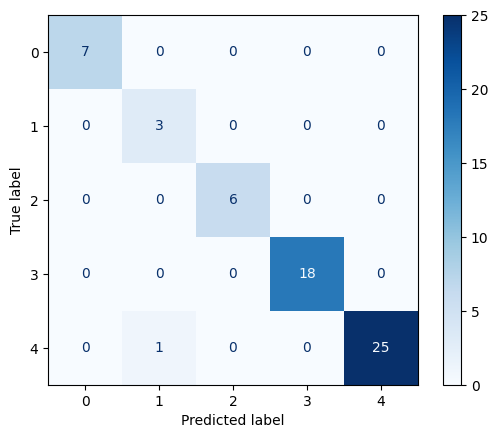

In [ ]:
pred_70 = grid_search_knn_70.predict(X_test30)
cm_70 = confusion_matrix(y_test30, pred_70)
ConfusionMatrixDisplay(confusion_matrix=cm_70).plot(cmap=plt.cm.Blues)
print("\nClassification Report (70/30):")
print(classification_report(y_test30, pred_70))
print("Accuracy:", accuracy_score(y_test30, pred_70))
print("Precision:", precision_score(y_test30, pred_70, average='macro'))
print("Recall:", recall_score(y_test30, pred_70, average='macro'))

In [ ]:
# Métricas para Test 20%
precision_80 = precision_score(y_test20, pred_KNN80, average='macro')
recall_80 = recall_score(y_test20, pred_KNN80, average='macro')
accuracy_80 = accuracy_score(y_test20, pred_KNN80)

# Métricas para Test 30%
precision_70 = precision_score(y_test30, pred_70, average='macro')
recall_70 = recall_score(y_test30, pred_70, average='macro')
accuracy_70 = accuracy_score(y_test30, pred_70)

#tabla de comparación
metricas_knn = pd.DataFrame({
    'Conjunto': ['Test 20%', 'Test 30%'],
    'Precision': [precision_80, precision_70],
    'Recall': [recall_80, recall_70],
    'Accuracy': [accuracy_80, accuracy_70]
})
# Mostrar tabla
print("\nComparación de métricas k-NN:")
print(metricas_knn)


Comparación de métricas k-NN:
   Conjunto  Precision    Recall  Accuracy
0  Test 20%   0.976471  0.963636  0.950000
1  Test 30%   0.950000  0.992308  0.983333


En ambos casos, el modelo logra métricas muy altas, lo cual sugiere una gran capacidad de generalización y una buena adecuación a los datos.
La pequeña diferencia en métricas podría deberse a la distribución específica de clases en cada conjunto, pero no afecta su rendimiento general.

# Comparacion de modelos

Realizaremos la comparacion de las metricas en los distintos modelos de clasificacion para el conjunto de test 80/20

In [ ]:
metricas_generales = pd.DataFrame({
    'Modelo': ['Arbol (80/20)','MultinomialNB (80/20)', 'GaussianNB (80/20)', 'KNN (80/20)'],
    'Precisión': [precision_20, precision_MNB20, precision_GNB20,precision_KNN20],
    'Exactitud': [accuracy_20, accuracy_MNB20, accuracy_GNB20,accuracy_KNN20 ],
    'Exhaustividad': [recall_20, recall_MNB20, recall_GNB20,recall_KNN20 ]})
print(metricas_generales)


                  Modelo  Precisión  Exactitud  Exhaustividad
0          Arbol (80/20)   1.000000      1.000       1.000000
1  MultinomialNB (80/20)   0.430108      0.575       0.375758
2     GaussianNB (80/20)   0.803535      0.800       0.888485
3            KNN (80/20)   0.976471      0.950       0.963636


# Conclusiones

Del análisis comparativo entre los distintos modelos aplicados para predecir el atributo Droga, se desprenden las siguientes observaciones:


*   El Árbol de Decisión obtuvo resultados perfectos en todas las métricas (Precisión, Exactitud y Exhaustividad). Si bien este desempeño puede parecer ideal, es importante evaluar si el modelo podría estar sobreajustado (overfitting), dado que se entrenó y evaluó en un conjunto relativamente pequeño, y su desempeño puede degradarse en datos nuevos.
*   El modelo Multinomial Naive Bayes presentó los peores resultados, con una precisión de apenas 0.43 y una exactitud del 57,5%. Este desempeño sugiere que el supuesto de independencia entre atributos categóricos y la forma en que se discretizan los valores numéricos no fue apropiado para este conjunto de datos.


* Gaussian Naive Bayes mostró un rendimiento mucho más aceptable, con una precisión del 80% y una exhaustividad del 88%. Estos resultados reflejan que el modelo pudo capturar adecuadamente la distribución normal de las variables numéricas, aunque aún fue superado por otros enfoques más complejos.

* El modelo k-Nearest Neighbors (k-NN) logró resultados muy altos: precisión del 97.6%, exactitud del 95% y exhaustividad del 96.3%. Este desempeño lo posiciona como uno de los modelos más efectivos en este contexto, posiblemente porque pudo aprovechar bien la estructura de los datos procesados (especialmente tras la estandarización y codificación adecuada).

*Conclusión Final*

Si bien el Árbol de Decisión y el k-NN ofrecieron los mejores resultados, es recomendable priorizar el modelo k-NN por su robustez y menor riesgo de sobreajuste. Los modelos basados en Naive Bayes fueron útiles como líneas base, pero suposiciones simplificadas limitaron su rendimiento frente a modelos más flexibles. En conjunto, este análisis destaca la importancia de probar distintos algoritmos y evaluar sus resultados cuantitativamente para seleccionar el más adecuado según el contexto y la naturaleza del problema.